# Iris Multivariate Analysis — Unit II: Univariate, Bivariate, and Multivariate Analysis

## Day 1: Univariate Analysis — Frequency Tables, Histograms, Density Plots, Boxplots, Violin Plots

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/iris.csv")
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
freq_table = df["species"].value_counts().reset_index()
freq_table.columns = ["Species", "Absolute_Frequency"]
freq_table["Relative_Frequency"] = (freq_table["Absolute_Frequency"] / len(df)).round(3)
freq_table["Cumulative_Frequency"] = freq_table["Absolute_Frequency"].cumsum()
freq_table

,Species,Absolute_Frequency,Relative_Frequency,Cumulative_Frequency
0,setosa,50,0.333,50
1,versicolor,50,0.333,100
2,virginica,50,0.333,150


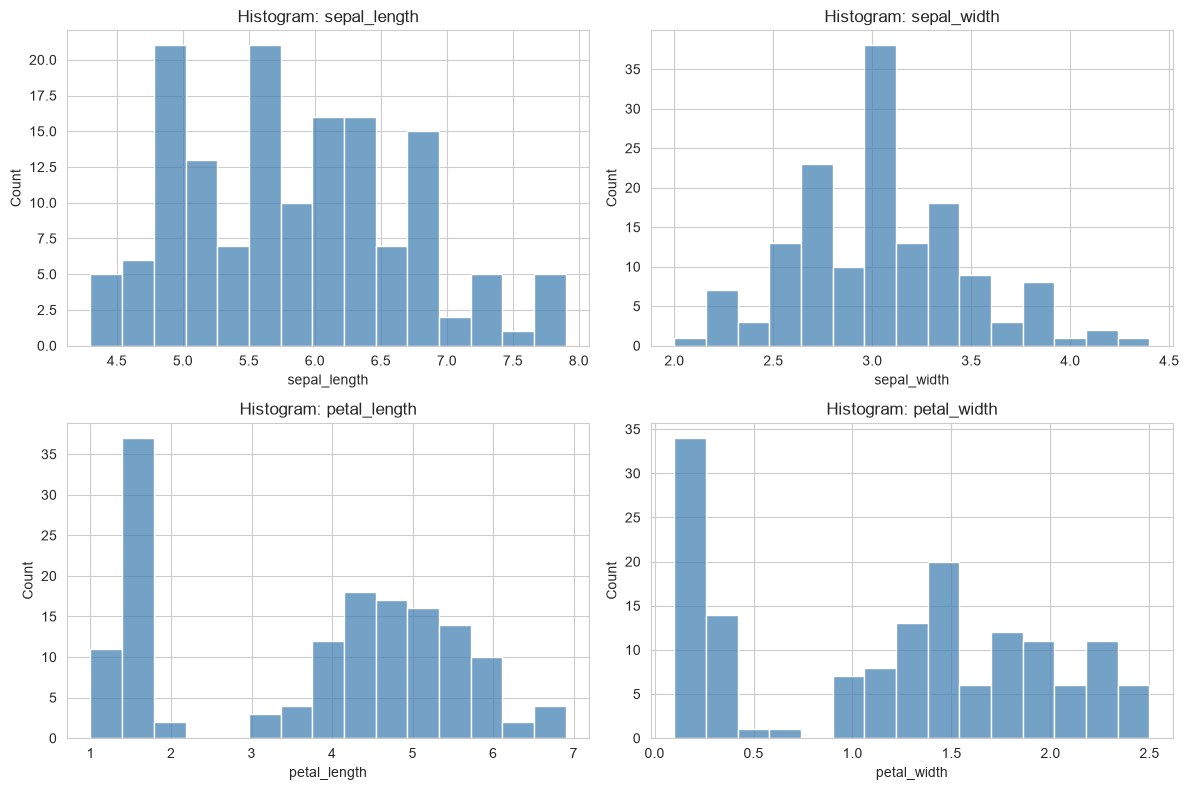

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=15, kde=False, ax=ax, color="steelblue")
    ax.set_title(f"Histogram: {col}")
plt.tight_layout()
plt.savefig("../outputs/day1_histograms.png", dpi=120)
plt.show()

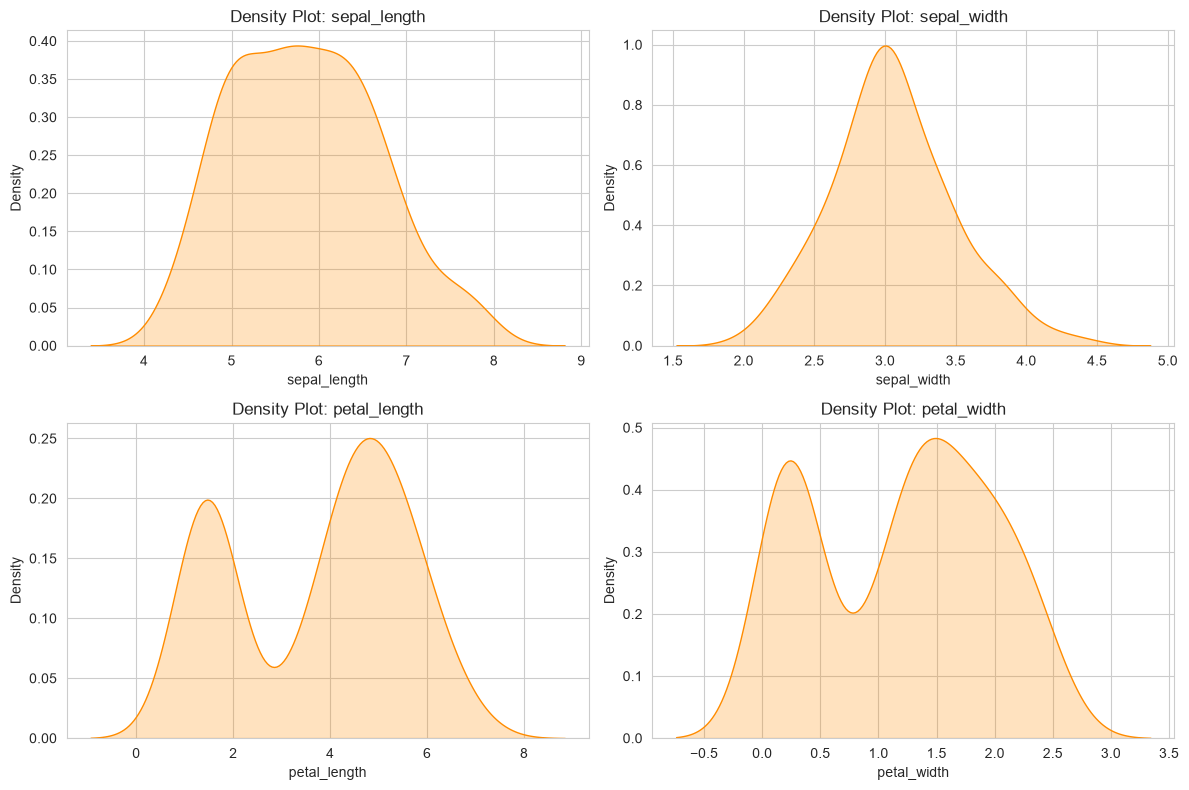

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(df[col], ax=ax, fill=True, color="darkorange")
    ax.set_title(f"Density Plot: {col}")
plt.tight_layout()
plt.savefig("../outputs/day1_density_plots.png", dpi=120)
plt.show()

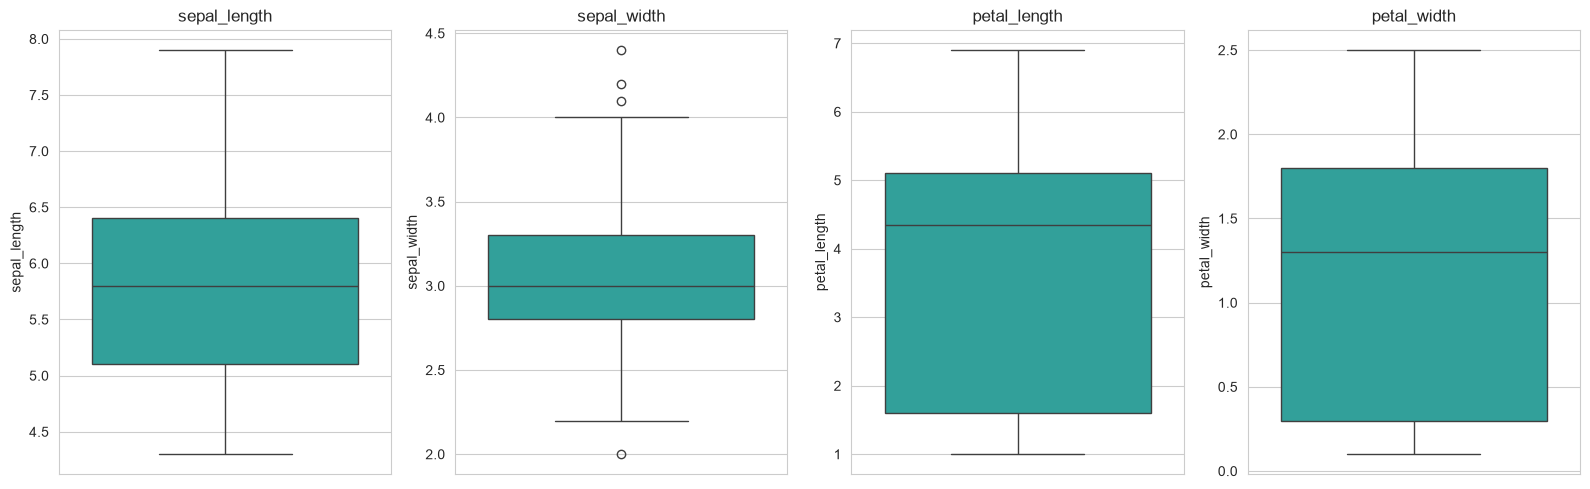

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../outputs/day1_boxplots.png", dpi=120)
plt.show()

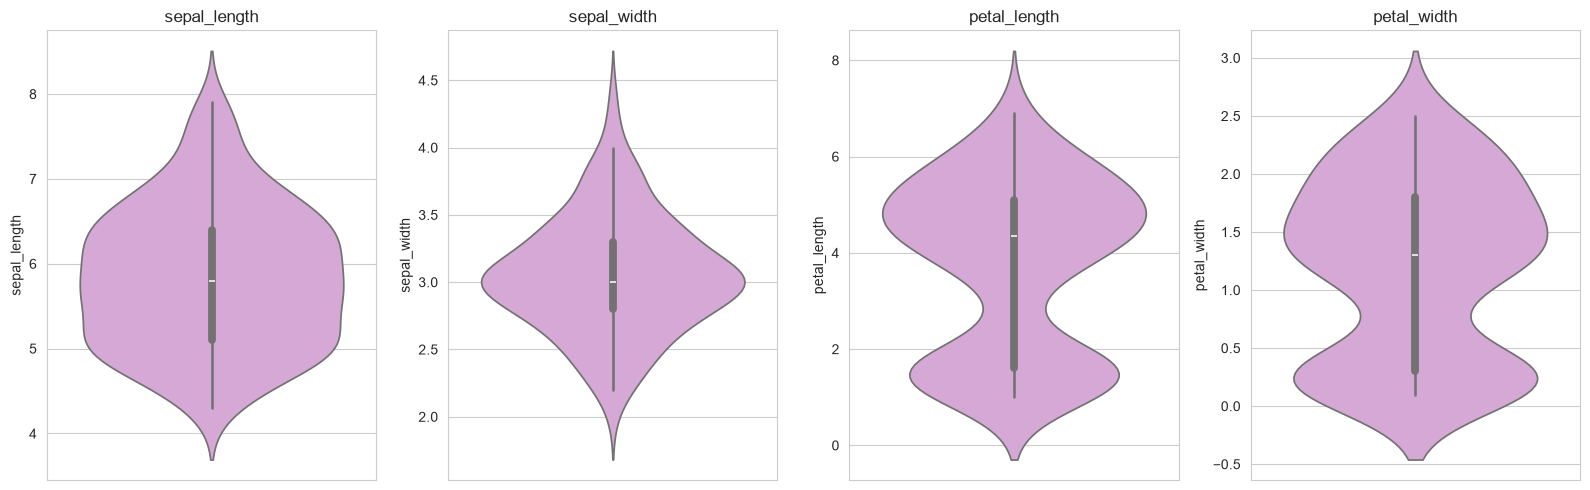

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.violinplot(y=df[col], ax=ax, color="plum")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../outputs/day1_violin_plots.png", dpi=120)
plt.show()

**Observation:** Histograms and density plots show the actual shape of each
variable's distribution (petal measurements appear bimodal — a cluster from
setosa, separated from versicolor/virginica). Boxplots summarize spread and
outliers compactly but hide this bimodal shape; violin plots recover it while
still marking the median, illustrating why shape-sensitive visuals matter
alongside boxplots.

## Day 2: Bivariate Analysis — Scatter Plots, Grouped Bar Plots, Covariance, Correlation

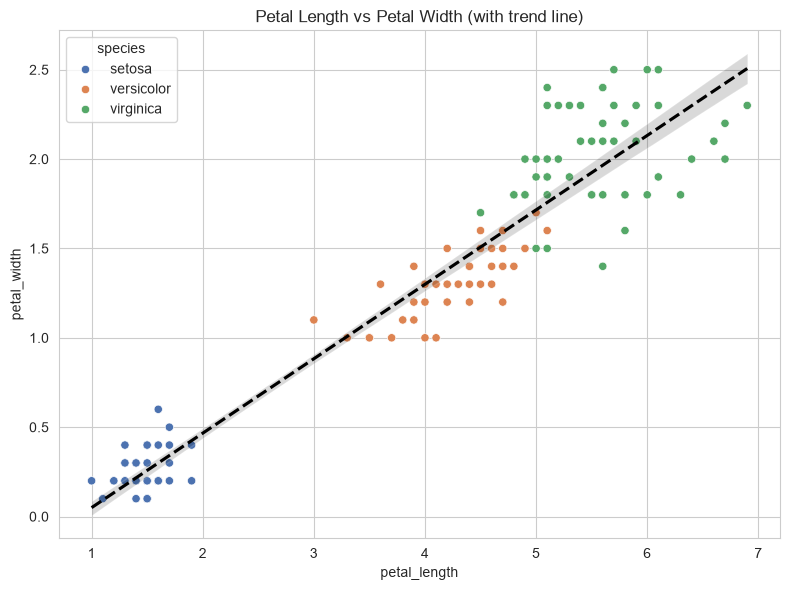

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", palette="deep")
sns.regplot(data=df, x="petal_length", y="petal_width", scatter=False, color="black", line_kws={"linestyle": "--"})
plt.title("Petal Length vs Petal Width (with trend line)")
plt.tight_layout()
plt.savefig("../outputs/day2_scatter_petal.png", dpi=120)
plt.show()

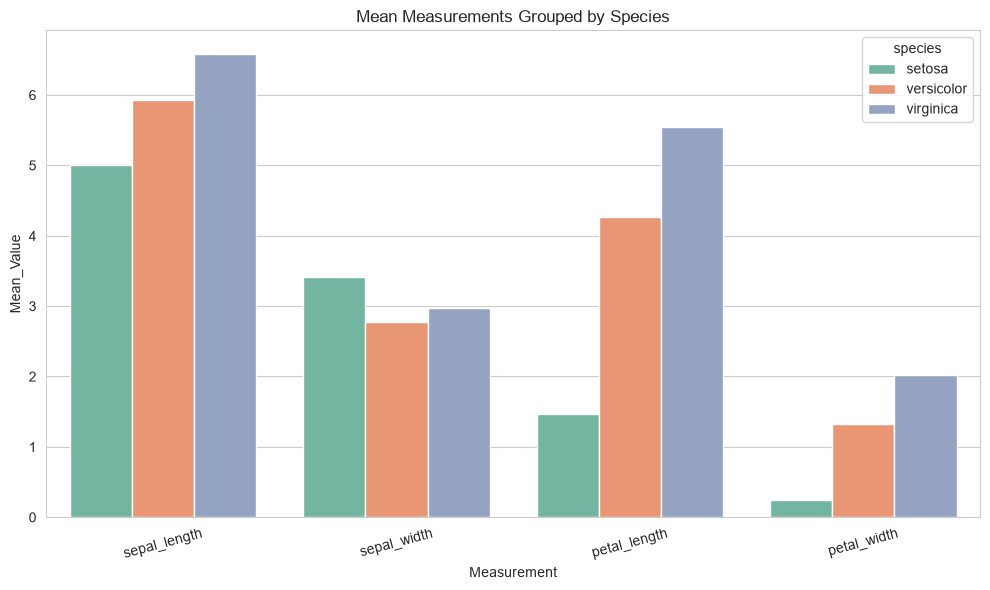

In [9]:
species_means = df.groupby("species")[numeric_cols].mean().reset_index()
species_means_melted = species_means.melt(id_vars="species", var_name="Measurement", value_name="Mean_Value")

plt.figure(figsize=(10, 6))
sns.barplot(data=species_means_melted, x="Measurement", y="Mean_Value", hue="species", palette="Set2")
plt.title("Mean Measurements Grouped by Species")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/day2_grouped_bar.png", dpi=120)
plt.show()

In [10]:
cov_matrix = df[numeric_cols].cov()
cov_matrix.round(2)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.69,-0.04,1.27,0.52
sepal_width,-0.04,0.19,-0.32,-0.12
petal_length,1.27,-0.32,3.11,1.30
petal_width,0.52,-0.12,1.30,0.58


In [11]:
corr_matrix = df[numeric_cols].corr()
corr_matrix.round(2)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.11,0.87,0.82
sepal_width,-0.11,1.00,-0.42,-0.36
petal_length,0.87,-0.42,1.00,0.96
petal_width,0.82,-0.36,0.96,1.00


**Observation:** Covariance values are hard to compare directly since they
depend on the units/scale of each variable (e.g., cm² here). Correlation
standardizes this into a unit-free measure between -1 and 1 — we can see
petal_length and petal_width are very strongly positively correlated
(~0.96), while sepal_width has weak/negative correlation with the others.

## Day 3: Multivariate Analysis — Heatmaps, Scatter Matrix, Pair Plots, Trends & Clusters

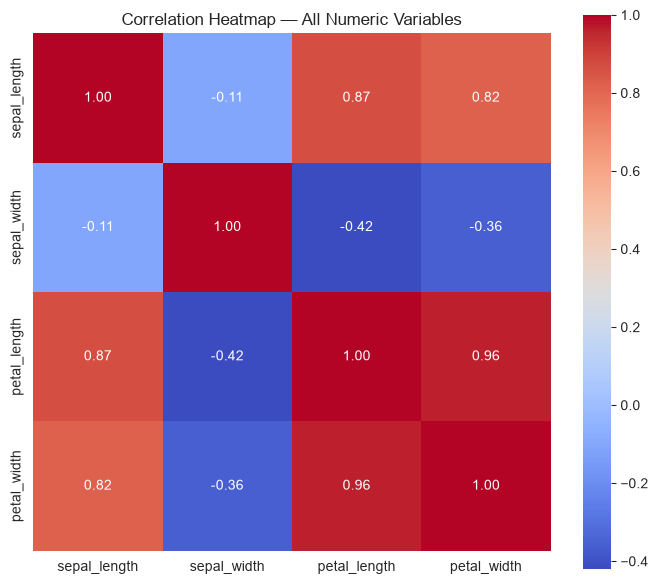

In [15]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap — All Numeric Variables")
plt.tight_layout()
plt.savefig("../outputs/day3_heatmap.png", dpi=120)
plt.show()

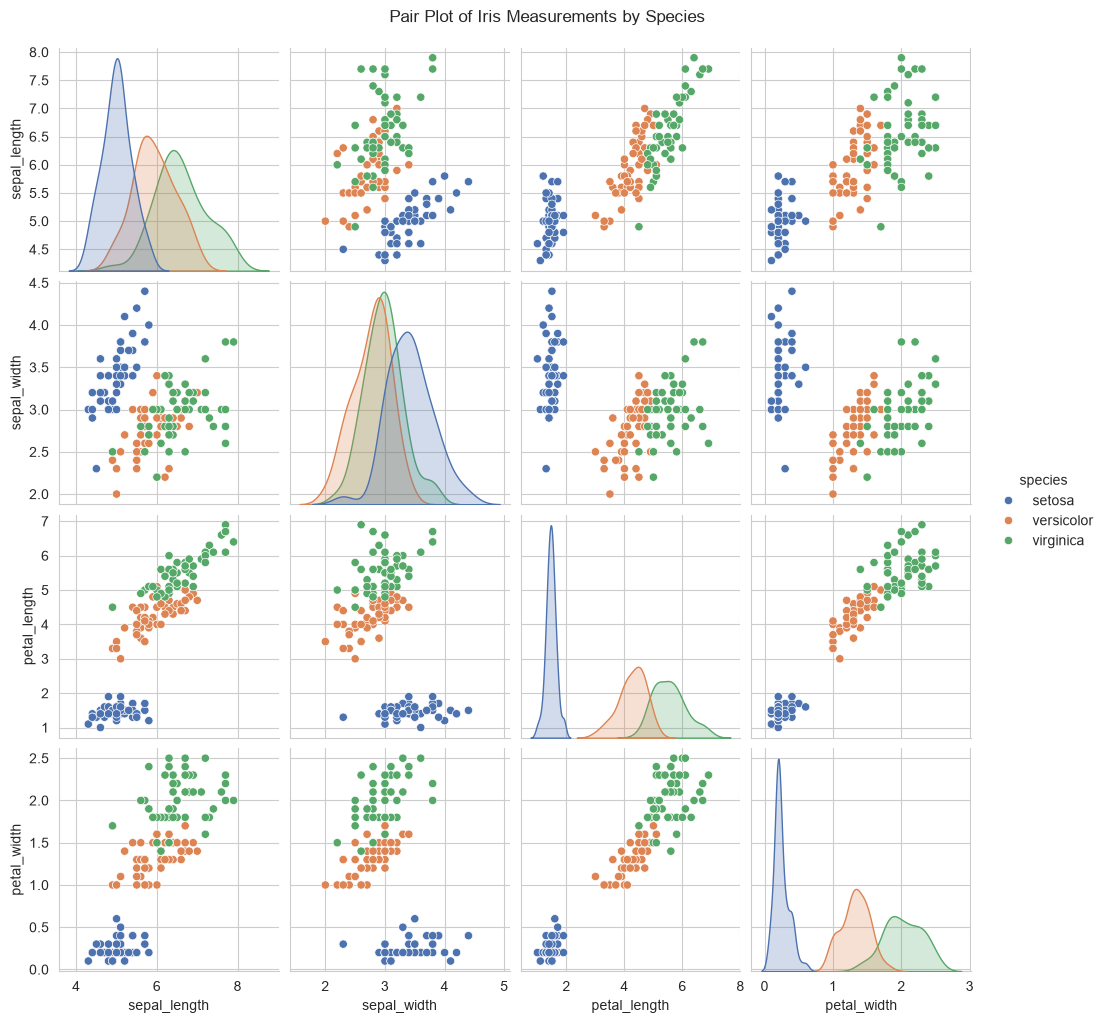

In [16]:
pairplot_fig = sns.pairplot(df, hue="species", vars=numeric_cols, palette="deep", diag_kind="kde")
pairplot_fig.fig.suptitle("Pair Plot of Iris Measurements by Species", y=1.02)
pairplot_fig.savefig("../outputs/day3_pairplot.png", dpi=120)
plt.show()

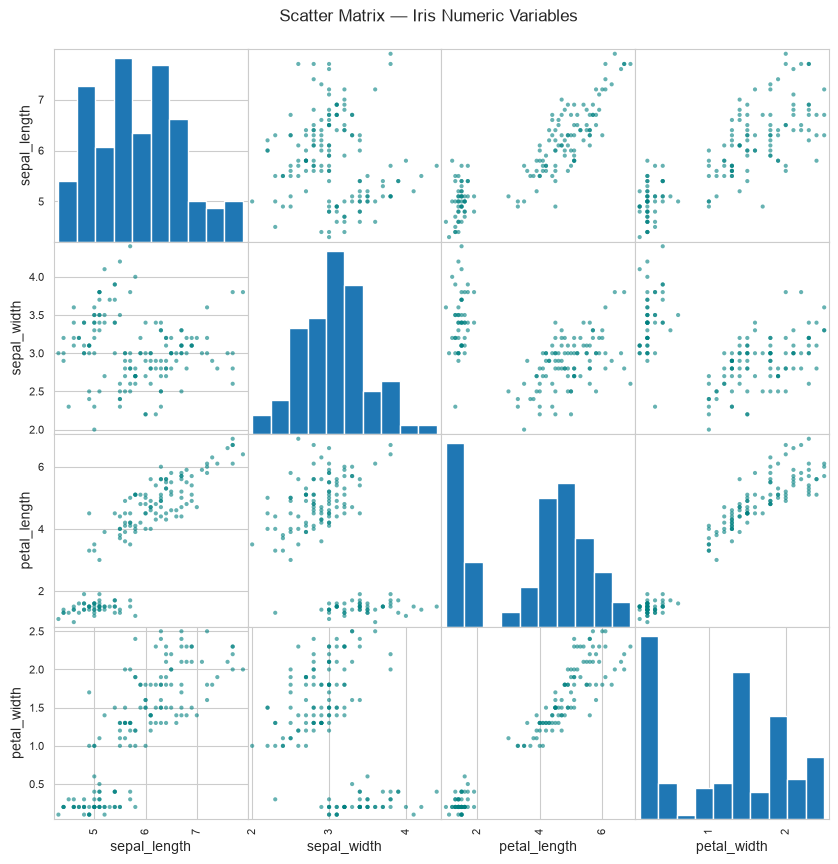

In [17]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[numeric_cols], figsize=(10, 10), diagonal="hist", color="teal", alpha=0.6)
plt.suptitle("Scatter Matrix — Iris Numeric Variables", y=0.92)
plt.savefig("../outputs/day3_scatter_matrix.png", dpi=120)
plt.show()

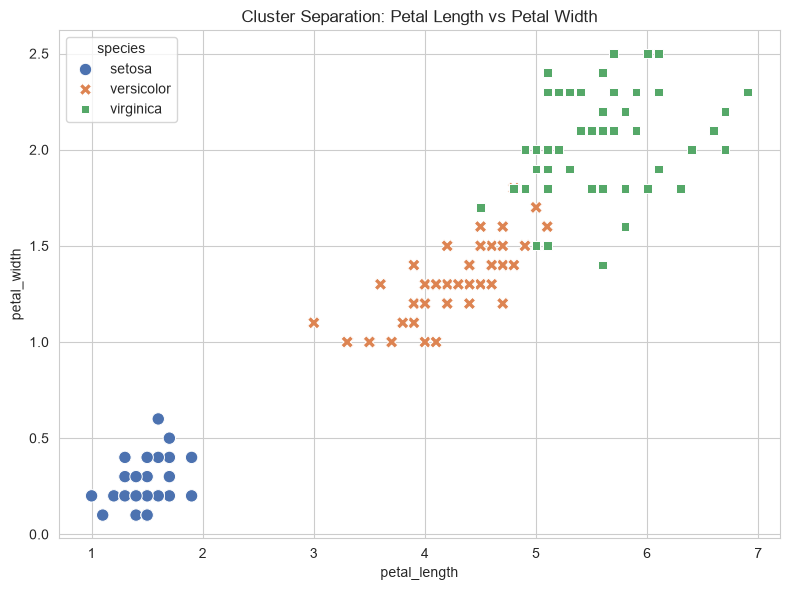

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", style="species", s=80, palette="deep")
plt.title("Cluster Separation: Petal Length vs Petal Width")
plt.tight_layout()
plt.savefig("../outputs/day3_cluster_view.png", dpi=120)
plt.show()

**Observation:** The heatmap confirms petal_length and petal_width are the
most strongly correlated pair (~0.96). The pair plot and scatter matrix
reveal that setosa forms a completely separate, tight cluster across nearly
every variable pair, while versicolor and virginica overlap more, especially
on sepal measurements — but remain reasonably distinguishable using petal
length/width. This kind of visual cluster separation is exactly what
multivariate analysis is meant to surface before applying any formal
clustering or classification algorithm.